### SNR Breakdown on Test Set

To better understand the robustness of the baseline model under different noise conditions, we evaluate performance separately for each SNR level in the test set.

**Metrics**
- F1 score
- False Alarm Rate (FAR)
- Miss Rate

In [2]:
from pathlib import Path
import sys
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from baseline_mlp import BaselineMLP
from metrics import compute_f1, compute_far, compute_miss_rate

# ===============================
# 3. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 4. Paths
# ===============================
TEST_DIR = PROJECT_ROOT / "data" / "generated" / "test"

feature_manifest_path = TEST_DIR / "features" / "test_noisy_features_manifest.jsonl"
noisy_manifest_path = TEST_DIR / "manifests" / "test_noisy_manifest.jsonl"

print("Feature manifest exists:", feature_manifest_path.exists())
print("Noisy manifest exists:", noisy_manifest_path.exists())

# ===============================
# 5. Load manifests
# ===============================
feature_rows = []
with open(feature_manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            feature_rows.append(json.loads(line))

noisy_rows = []
with open(noisy_manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            noisy_rows.append(json.loads(line))

print("Number of feature rows:", len(feature_rows))
print("Number of noisy manifest rows:", len(noisy_rows))

# ===============================
# 6. Build ex_id -> snr mapping
# ===============================
snr_map = {}
for row in noisy_rows:
    ex_id = row["ex_id"]
    noise_info = row.get("noise", {})
    snr_db = noise_info.get("snr_db_target", None)
    snr_map[ex_id] = snr_db

# Check unique SNR values
unique_snrs = sorted(set(v for v in snr_map.values() if v is not None))
print("Unique SNR values:", unique_snrs)

# ===============================
# 7. Load final best model from checkpoint file
# ===============================
checkpoint_path = PROJECT_ROOT / "results" / "baseline_mlp_noisy" / "best_model.pt"
print("Checkpoint exists:", checkpoint_path.exists())
print("Checkpoint path:", checkpoint_path)

model_snr = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)

state_dict = torch.load(checkpoint_path, map_location=device)
model_snr.load_state_dict(state_dict)
model_snr.eval()

# ===============================
# 8. Initialize accumulators
# ===============================
snr_stats = {}
for snr in unique_snrs:
    snr_stats[snr] = {
        "tp": 0,
        "tn": 0,
        "fp": 0,
        "fn": 0,
        "num_examples": 0,
        "num_frames": 0,
    }

threshold = 0.5

# ===============================
# 9. Run inference example by example
# ===============================
with torch.no_grad():
    for row in feature_rows:
        ex_id = row["ex_id"]
        snr_db = snr_map.get(ex_id, None)

        if snr_db is None:
            continue

        stacked_path = TEST_DIR / row["stacked_features_path"]
        label_path = TEST_DIR / row["stacked_labels_path"]

        X = np.load(stacked_path).astype(np.float32, copy=False)
        y = np.load(label_path).astype(np.int64, copy=False)

        x_tensor = torch.from_numpy(np.array(X, dtype=np.float32, copy=True)).to(device)
        y_tensor = torch.from_numpy(y).to(device)

        logits = model_snr(x_tensor)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).to(torch.int64)

        tp = ((y_tensor == 1) & (preds == 1)).sum().item()
        tn = ((y_tensor == 0) & (preds == 0)).sum().item()
        fp = ((y_tensor == 0) & (preds == 1)).sum().item()
        fn = ((y_tensor == 1) & (preds == 0)).sum().item()

        snr_stats[snr_db]["tp"] += tp
        snr_stats[snr_db]["tn"] += tn
        snr_stats[snr_db]["fp"] += fp
        snr_stats[snr_db]["fn"] += fn
        snr_stats[snr_db]["num_examples"] += 1
        snr_stats[snr_db]["num_frames"] += len(y)

# ===============================
# 10. Compute metrics per SNR
# ===============================
snr_results = []

for snr in unique_snrs:
    tp = snr_stats[snr]["tp"]
    tn = snr_stats[snr]["tn"]
    fp = snr_stats[snr]["fp"]
    fn = snr_stats[snr]["fn"]

    f1 = compute_f1(tp, fp, fn)
    far = compute_far(fp, tn)
    miss = compute_miss_rate(fn, tp)

    snr_results.append({
        "snr_db": snr,
        "f1": f1,
        "far": far,
        "miss_rate": miss,
        "num_examples": snr_stats[snr]["num_examples"],
        "num_frames": snr_stats[snr]["num_frames"],
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    })

# ===============================
# 11. Print results
# ===============================
print("\n===== SNR Breakdown on Test Set =====")
for row in snr_results:
    print(
        f"SNR={row['snr_db']:>4} dB | "
        f"F1={row['f1']:.6f} | "
        f"FAR={row['far']:.6f} | "
        f"Miss={row['miss_rate']:.6f} | "
        f"Examples={row['num_examples']} | "
        f"Frames={row['num_frames']}"
    )

Using device: cpu
Feature manifest exists: True
Noisy manifest exists: True
Number of feature rows: 500
Number of noisy manifest rows: 500
Unique SNR values: [-5.0, 0.0, 5.0, 10.0, 20.0]
Checkpoint exists: True
Checkpoint path: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/results/baseline_mlp_noisy/best_model.pt

===== SNR Breakdown on Test Set =====
SNR=-5.0 dB | F1=0.860988 | FAR=0.441843 | Miss=0.096374 | Examples=110 | Frames=239178
SNR= 0.0 dB | F1=0.879337 | FAR=0.329768 | Miss=0.101285 | Examples=93 | Frames=205028
SNR= 5.0 dB | F1=0.896533 | FAR=0.253401 | Miss=0.096608 | Examples=101 | Frames=224343
SNR=10.0 dB | F1=0.902673 | FAR=0.194664 | Miss=0.105196 | Examples=106 | Frames=222779
SNR=20.0 dB | F1=0.912947 | FAR=0.169715 | Miss=0.094928 | Examples=90 | Frames=195355


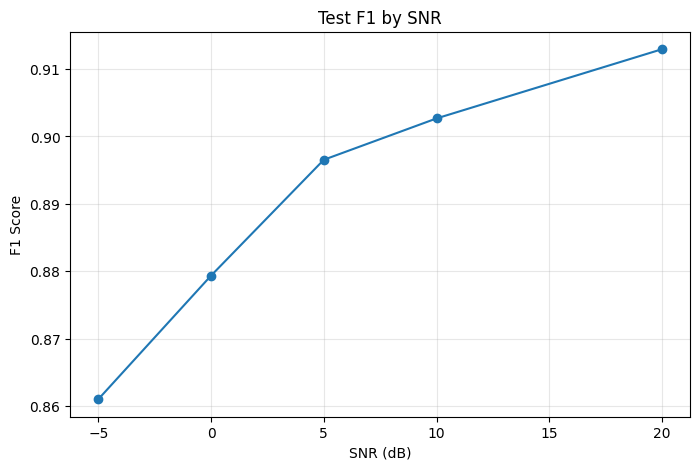

In [3]:
# F1 vs SNR
snr_values = [row["snr_db"] for row in snr_results]
f1_values = [row["f1"] for row in snr_results]

plt.figure(figsize=(8, 5))
plt.plot(snr_values, f1_values, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("F1 Score")
plt.title("Test F1 by SNR")
plt.grid(True, alpha=0.3)
plt.show()

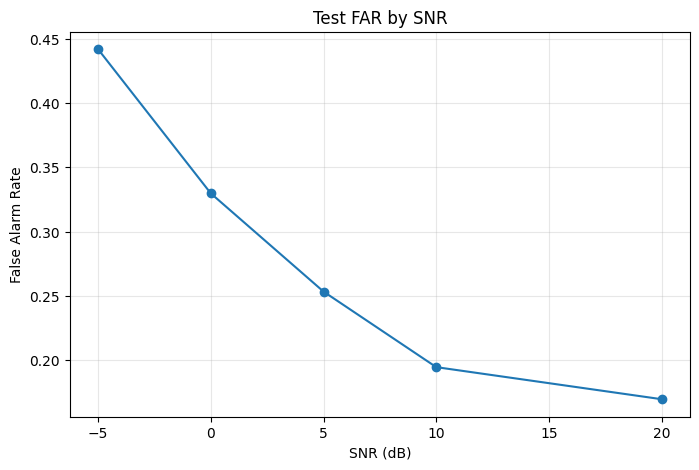

In [4]:
#FAR vs SNR
far_values = [row["far"] for row in snr_results]

plt.figure(figsize=(8, 5))
plt.plot(snr_values, far_values, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("False Alarm Rate")
plt.title("Test FAR by SNR")
plt.grid(True, alpha=0.3)
plt.show()

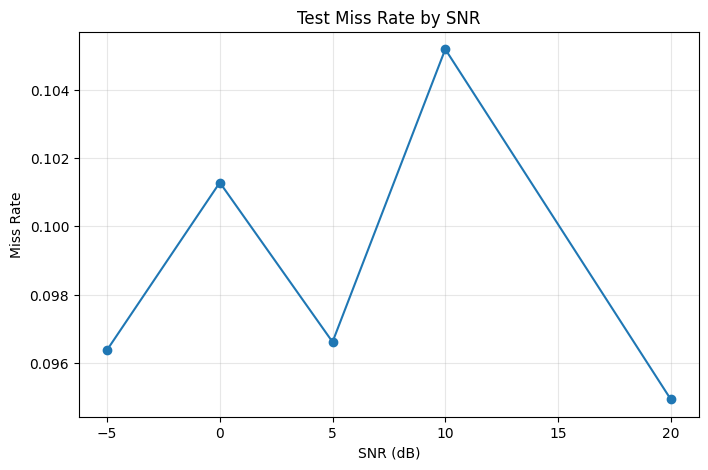

In [5]:
# Miss Rate vs SNR 
miss_values = [row["miss_rate"] for row in snr_results]

plt.figure(figsize=(8, 5))
plt.plot(snr_values, miss_values, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Miss Rate")
plt.title("Test Miss Rate by SNR")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
print("\nSNR Breakdown Table")
print("-" * 80)
print(f"{'SNR(dB)':<10}{'F1':<12}{'FAR':<12}{'Miss Rate':<15}{'Examples':<12}{'Frames':<12}")

for row in snr_results:
    print(
        f"{str(row['snr_db']):<10}"
        f"{row['f1']:<12.6f}"
        f"{row['far']:<12.6f}"
        f"{row['miss_rate']:<15.6f}"
        f"{row['num_examples']:<12}"
        f"{row['num_frames']:<12}"
    )


SNR Breakdown Table
--------------------------------------------------------------------------------
SNR(dB)   F1          FAR         Miss Rate      Examples    Frames      
-5.0      0.860988    0.441843    0.096374       110         239178      
0.0       0.879337    0.329768    0.101285       93          205028      
5.0       0.896533    0.253401    0.096608       101         224343      
10.0      0.902673    0.194664    0.105196       106         222779      
20.0      0.912947    0.169715    0.094928       90          195355      


#### SNR Breakdown Analysis

We evaluated the baseline model under different SNR conditions to better understand its robustness to noise.

**Results**
- F1 score increases steadily from 0.861 at -5 dB to 0.913 at 20 dB.
- False Alarm Rate (FAR) decreases significantly as SNR increases.
- Miss Rate remains relatively stable across all SNR levels.

**Key Observations**
- At low SNR (-5 dB), the model suffers from a high FAR (0.44), indicating that noise is frequently misclassified as speech.
- As SNR improves, FAR drops substantially, showing that the model becomes more reliable in cleaner conditions.
- The relatively stable Miss Rate suggests that the model consistently detects speech segments, even under noisy conditions.

**Conclusion**
The baseline model demonstrates strong speech detection capability but limited robustness to noise. The primary weakness lies in its high false alarm rate under low SNR conditions.

This analysis motivates the need for noise-robust training strategies, which will be explored in Stage 2.

### Noise Type Breakdown on Test Set

To further analyze the robustness of the baseline model, we evaluate test performance separately for each noise type.

**Metrics**
- F1 score
- False Alarm Rate (FAR)
- Miss Rate

This analysis complements the SNR-based evaluation by showing how the model behaves under different categories of background noise.

In [7]:
from pathlib import Path
import sys
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from baseline_mlp import BaselineMLP
from metrics import compute_f1, compute_far, compute_miss_rate

# ===============================
# 3. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 4. Paths
# ===============================
TEST_DIR = PROJECT_ROOT / "data" / "generated" / "test"

feature_manifest_path = TEST_DIR / "features" / "test_noisy_features_manifest.jsonl"
noisy_manifest_path = TEST_DIR / "manifests" / "test_noisy_manifest.jsonl"
checkpoint_path = PROJECT_ROOT / "results" / "baseline_mlp_noisy" / "best_model.pt"

print("Feature manifest exists:", feature_manifest_path.exists())
print("Noisy manifest exists:", noisy_manifest_path.exists())
print("Checkpoint exists:", checkpoint_path.exists())

# ===============================
# 5. Load manifests
# ===============================
feature_rows = []
with open(feature_manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            feature_rows.append(json.loads(line))

noisy_rows = []
with open(noisy_manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            noisy_rows.append(json.loads(line))

print("Number of feature rows:", len(feature_rows))
print("Number of noisy manifest rows:", len(noisy_rows))

# ===============================
# 6. Build ex_id -> noise_type mapping
# ===============================
noise_type_map = {}
for row in noisy_rows:
    ex_id = row["ex_id"]
    noise_info = row.get("noise", {})
    noise_type = noise_info.get("noise_type", "unknown")
    noise_type_map[ex_id] = noise_type

unique_noise_types = sorted(set(noise_type_map.values()))
print("Unique noise types:", unique_noise_types)

# ===============================
# 7. Load final best model
# ===============================
model_noise = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)

state_dict = torch.load(checkpoint_path, map_location=device)
model_noise.load_state_dict(state_dict)
model_noise.eval()

# ===============================
# 8. Initialize accumulators
# ===============================
noise_stats = {}
for noise_type in unique_noise_types:
    noise_stats[noise_type] = {
        "tp": 0,
        "tn": 0,
        "fp": 0,
        "fn": 0,
        "num_examples": 0,
        "num_frames": 0,
    }

threshold = 0.5

# ===============================
# 9. Run inference example by example
# ===============================
with torch.no_grad():
    for row in feature_rows:
        ex_id = row["ex_id"]
        noise_type = noise_type_map.get(ex_id, "unknown")

        stacked_path = TEST_DIR / row["stacked_features_path"]
        label_path = TEST_DIR / row["stacked_labels_path"]

        X = np.load(stacked_path).astype(np.float32, copy=False)
        y = np.load(label_path).astype(np.int64, copy=False)

        x_tensor = torch.from_numpy(np.array(X, dtype=np.float32, copy=True)).to(device)
        y_tensor = torch.from_numpy(y).to(device)

        logits = model_noise(x_tensor)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).to(torch.int64)

        tp = ((y_tensor == 1) & (preds == 1)).sum().item()
        tn = ((y_tensor == 0) & (preds == 0)).sum().item()
        fp = ((y_tensor == 0) & (preds == 1)).sum().item()
        fn = ((y_tensor == 1) & (preds == 0)).sum().item()

        noise_stats[noise_type]["tp"] += tp
        noise_stats[noise_type]["tn"] += tn
        noise_stats[noise_type]["fp"] += fp
        noise_stats[noise_type]["fn"] += fn
        noise_stats[noise_type]["num_examples"] += 1
        noise_stats[noise_type]["num_frames"] += len(y)

# ===============================
# 10. Compute metrics per noise type
# ===============================
noise_results = []

for noise_type in unique_noise_types:
    tp = noise_stats[noise_type]["tp"]
    tn = noise_stats[noise_type]["tn"]
    fp = noise_stats[noise_type]["fp"]
    fn = noise_stats[noise_type]["fn"]

    f1 = compute_f1(tp, fp, fn)
    far = compute_far(fp, tn)
    miss = compute_miss_rate(fn, tp)

    noise_results.append({
        "noise_type": noise_type,
        "f1": f1,
        "far": far,
        "miss_rate": miss,
        "num_examples": noise_stats[noise_type]["num_examples"],
        "num_frames": noise_stats[noise_type]["num_frames"],
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    })

# ===============================
# 11. Print results
# ===============================
print("\n===== Noise Type Breakdown on Test Set =====")
for row in noise_results:
    print(
        f"NoiseType={row['noise_type']:<10} | "
        f"F1={row['f1']:.6f} | "
        f"FAR={row['far']:.6f} | "
        f"Miss={row['miss_rate']:.6f} | "
        f"Examples={row['num_examples']} | "
        f"Frames={row['num_frames']}"
    )

Using device: cpu
Feature manifest exists: True
Noisy manifest exists: True
Checkpoint exists: True
Number of feature rows: 500
Number of noisy manifest rows: 500
Unique noise types: ['babble', 'music', 'noise']

===== Noise Type Breakdown on Test Set =====
NoiseType=babble     | F1=0.933686 | FAR=0.158104 | Miss=0.064066 | Examples=94 | Frames=206343
NoiseType=music      | F1=0.863893 | FAR=0.389008 | Miss=0.104551 | Examples=146 | Frames=317111
NoiseType=noise      | F1=0.887445 | FAR=0.264363 | Miss=0.108581 | Examples=260 | Frames=563229


In [8]:
print("\nNoise Type Breakdown Table")
print("-" * 90)
print(f"{'Noise Type':<12}{'F1':<12}{'FAR':<12}{'Miss Rate':<15}{'Examples':<12}{'Frames':<12}")

for row in noise_results:
    print(
        f"{row['noise_type']:<12}"
        f"{row['f1']:<12.6f}"
        f"{row['far']:<12.6f}"
        f"{row['miss_rate']:<15.6f}"
        f"{row['num_examples']:<12}"
        f"{row['num_frames']:<12}"
    )


Noise Type Breakdown Table
------------------------------------------------------------------------------------------
Noise Type  F1          FAR         Miss Rate      Examples    Frames      
babble      0.933686    0.158104    0.064066       94          206343      
music       0.863893    0.389008    0.104551       146         317111      
noise       0.887445    0.264363    0.108581       260         563229      


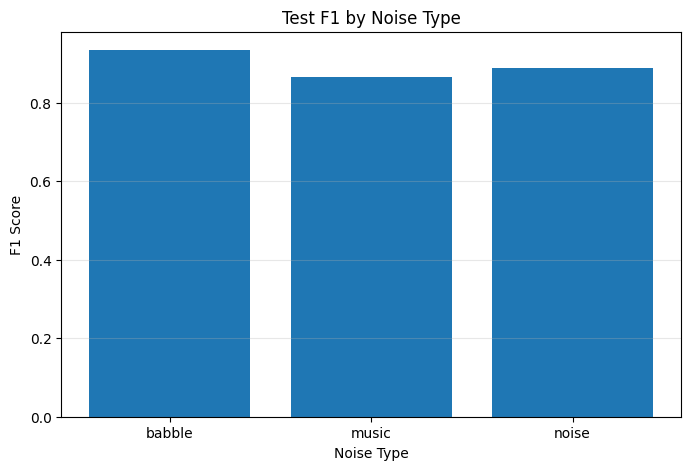

In [9]:
# F1 by noise type
noise_types = [row["noise_type"] for row in noise_results]
f1_values = [row["f1"] for row in noise_results]

plt.figure(figsize=(8, 5))
plt.bar(noise_types, f1_values)
plt.xlabel("Noise Type")
plt.ylabel("F1 Score")
plt.title("Test F1 by Noise Type")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

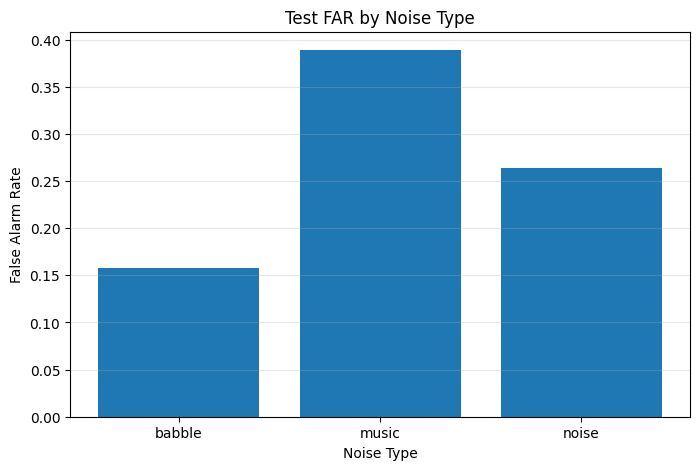

In [10]:
# FAR by noise type
far_values = [row["far"] for row in noise_results]

plt.figure(figsize=(8, 5))
plt.bar(noise_types, far_values)
plt.xlabel("Noise Type")
plt.ylabel("False Alarm Rate")
plt.title("Test FAR by Noise Type")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

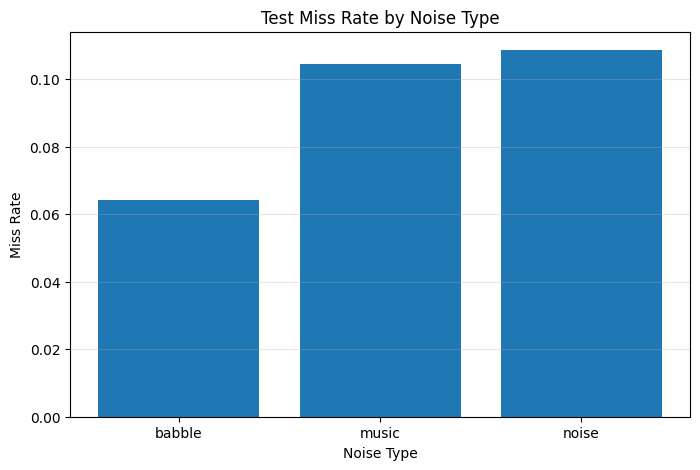

In [11]:
# Miss Rate by noise type
miss_values = [row["miss_rate"] for row in noise_results]

plt.figure(figsize=(8, 5))
plt.bar(noise_types, miss_values)
plt.xlabel("Noise Type")
plt.ylabel("Miss Rate")
plt.title("Test Miss Rate by Noise Type")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Noise Type Breakdown Analysis

To further understand the robustness of the baseline model, we evaluate performance across different noise types: **babble**, **music**, and **noise**.

### Results Summary

| Noise Type | F1 Score | FAR | Miss Rate |
|------------|----------|-----|-----------|
| Babble     | 0.9337   | 0.1581 | 0.0641 |
| Music      | 0.8639   | 0.3890 | 0.1046 |
| Noise      | 0.8874   | 0.2644 | 0.1086 |

### Key Observations

- **Babble noise achieves the best performance**
  - Highest F1 score (0.9337)
  - Lowest FAR (0.1581) and lowest miss rate (0.0641)
  - This suggests the model is relatively robust when multiple speakers are present.

- **Music noise is the most challenging condition**
  - Lowest F1 score (0.8639)
  - Highest FAR (0.3890)
  - This indicates the model frequently misclassifies music as speech.
  - This is expected because music often shares spectral patterns with speech.

- **General noise (e.g., ambient/background) shows moderate difficulty**
  - Performance lies between babble and music
  - FAR is lower than music but higher than babble

### Interpretation

- The main weakness of the baseline model lies in **false alarms under music noise**.
- The model tends to confuse structured acoustic patterns (like music) with speech.
- In contrast, babble noise—despite being complex—does not trigger as many false positives.

### Conclusion

This noise-type breakdown complements the SNR analysis by revealing that:

- **Noise intensity (SNR) affects overall difficulty**
- **Noise type determines the kind of errors (FAR vs Miss)**

Overall, the baseline MLP is:
- Robust to babble noise
- Moderately robust to generic noise
- Weakest under music noise

This insight provides motivation for future improvements in Stage 2, such as:
- better temporal modeling (CRNN)
- or more targeted noise augmentation strategies